# NovaX — Credit Card Default Risk Analysis
 
NovaX analyzes customer financial data to identify patterns of loan default risk using data science techniques. The project helps financial institutions make better loan-approval decisions by predicting which customers are likely to default, using the UCI **"Default of Credit Card Clients"** dataset (30,000 rows × 25 columns).
 
## Project Pipeline
 
The notebook (`Credit_Risk_Analytics.ipynb`) is organized into sequential phases, each handled by a different team member.

## Team
 
| Member | Role | Status |
|---|---|---|
| Member 1 | Data Engineer — cleaning, feature engineering | ✅ Implemented |
| Member 2 | Data Analyst — exploratory data analysis & statistical testing | ✅ Implemented |
| Member 3 | Visualization Specialist — charts & report figures | ✅ Implemented |
| Member 4 | Risk Model Developer — 3-dimension weighted risk scoring & segmentation | ✅ Implemented |
| Member 5 | Business Analyst + API Developer — external economic data, strategy & recommendations | ✅ Implemented |
 


# Member 1 — Data Engineering

Loads the raw UCI credit-card dataset, cleans it, and hands off a ready-to-use file for the rest of the team.

**Work done:**
- Loaded the raw CSV (handling its known extra header row) and validated the shape (30,000 × 25)
- Renamed columns to clean snake_case, decoded SEX/EDUCATION/MARRIAGE codes into labels
- Removed duplicates, flagged invalid ages and repayment codes, dropped genuinely bad rows
- Engineered new features: average bill/payment amounts, payment-to-bill ratio, delinquency counts, balance trend, credit utilisation, age bands, credit-limit tiers
- Exported `cleaned_credit_data.csv` and `data_dictionary_cleaned.csv`

**Special features:**
- Undocumented category codes (e.g. education 0/5/6) are kept as an explicit `"Unknown/Other"` label instead of being dropped or merged
- Outliers are flagged, not deleted — preserved for downstream analysis
- Every cleaning step is a documented, testable function

In [31]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
import os
import requests
import time

warnings.filterwarnings("ignore")

# Display / plotting defaults
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110

RAW_DATA_PATH = Path("default of credit card clients.csv")
CLEAN_DATA_PATH = Path("cleaned_credit_data.csv")
DATA_DICTIONARY_PATH = Path("data_dictionary_cleaned.csv")

RANDOM_STATE = 42
print("Environment ready.")


Environment ready.


## 1. Load Data

We ingest the **exact CSV file supplied by the project team**
(`default_of_credit_card_clients_-_default_of_credit_card_clients.csv`) into a Pandas DataFrame
and immediately validate the shape against the UCI documentation: **30,000 rows × 25 columns**
(1 ID, 23 predictors, 1 target). Any mismatch here would indicate a corrupted download or a
wrong file, so we fail fast with an assertion rather than silently continuing.

**File-format note:** this particular export has a non-standard layout — row 1 is a generic
`X1, X2, ..., X23, Y` header (an artefact of the export tool used to produce the file), and the
*real* column names (`ID`, `LIMIT_BAL`, ...) sit on row 2. We therefore load with `header=1` to
skip the artefact row and use the true column names. This is handled explicitly and documented
below rather than silently guessed.


In [32]:
def load_raw_data(path: Path) -> pd.DataFrame:
    """Load the raw credit-card dataset exactly as supplied and validate its shape.

    The supplied CSV has a known non-standard layout: an extra generic
    ``X1, X2, ..., Y`` row precedes the real header row. ``header=1`` skips
    that artefact row and uses the true column names on row 2.

    Parameters
    ----------
    path : Path
        Location of the raw CSV file.

    Returns
    -------
    pd.DataFrame
        The raw, unmodified dataset (real column names, no artefact row).

    Raises
    ------
    FileNotFoundError
        If the file does not exist at the given path.
    AssertionError
        If the loaded shape does not match the documented 30,000 x 25 dataset.
    """
    if not path.exists():
        raise FileNotFoundError(f"Raw data file not found at: {path.resolve()}")

    df_raw = pd.read_csv(path, header=1)

    expected_rows, expected_cols = 30_000, 25
    assert df_raw.shape == (expected_rows, expected_cols), (
        f"Unexpected shape {df_raw.shape}; expected ({expected_rows}, {expected_cols}). "
        "Verify the source file matches the UCI 'Default of Credit Card Clients' dataset."
    )
    return df_raw


df_raw = load_raw_data(RAW_DATA_PATH)
print(f"Source file: {RAW_DATA_PATH.name}")
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")
print(f"Row/column count matches UCI documentation: {df_raw.shape == (30000, 25)}")
df_raw.head()


Source file: default of credit card clients.csv
Loaded 30,000 rows and 25 columns.
Row/column count matches UCI documentation: True


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Initial Data Assessment

Before touching the data we audit it: structure, summary statistics for *every* column
(`include='all'` surfaces categorical-looking numeric codes too), missing values, and the raw
category codes for the demographic fields and the six repayment-status fields.


In [33]:
print("--- Dataset Information ---")
df_raw.info()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_1                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000

In [34]:
df_raw.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [35]:
missing_summary = (
    df_raw.isnull()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: (d["missing_count"] / len(df_raw) * 100).round(3))
    .sort_values("missing_count", ascending=False)
)
print("Columns with missing values:", (missing_summary["missing_count"] > 0).sum())
missing_summary.head(10)


Columns with missing values: 0


,missing_count,missing_pct
ID,0,0.0
BILL_AMT2,0,0.0
PAY_AMT6,0,0.0
PAY_AMT5,0,0.0
PAY_AMT4,0,0.0
PAY_AMT3,0,0.0
PAY_AMT2,0,0.0
PAY_AMT1,0,0.0
BILL_AMT6,0,0.0
BILL_AMT5,0,0.0


In [36]:
print("Raw SEX codes:\n", df_raw["SEX"].value_counts(dropna=False), "\n")
print("Raw EDUCATION codes:\n", df_raw["EDUCATION"].value_counts(dropna=False), "\n")
print("Raw MARRIAGE codes:\n", df_raw["MARRIAGE"].value_counts(dropna=False), "\n")

pay_cols_raw = [c for c in df_raw.columns if c.startswith("PAY_") and not c.startswith("PAY_AMT")]
print("Repayment-status columns:", pay_cols_raw)
for c in pay_cols_raw:
    print(f"\n{c} value counts:\n", df_raw[c].value_counts().sort_index())

Raw SEX codes:
 SEX
2    18112
1    11888
Name: count, dtype: int64 

Raw EDUCATION codes:
 EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64 

Raw MARRIAGE codes:
 MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64 

Repayment-status columns: ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

PAY_1 value counts:
 PAY_1
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2 value counts:
 PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3 value counts:
 PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4 value counts:
 PAY_4
-2     4348
-1     5687


**Observations from the initial assessment**

- No nulls are present in this extract — the "missing data" challenge here is really an
  *undocumented / invalid category* problem rather than a `NaN` problem (see `EDUCATION` codes
  `0, 5, 6` and `MARRIAGE` code `0`, none of which appear in the official UCI documentation).
- `PAY_1`–`PAY_6` contain a `-2` code
  ("no consumption") in addition to the documented `-1` ("paid duly") and `1..9`
  ("months delayed"). We will preserve `-2` and `-1` as distinct "no-delay" states rather than
  collapsing them, since a customer with no card usage is behaviourally different from one who
  pays in full.
- `LIMIT_BAL`, `BILL_AMT*` and `PAY_AMT*` are heavily right-skewed (mean far above median),
  which we account for later using IQR-based outlier flags rather than hard trimming.


## 3. Rename Columns

Raw column names mix cryptic abbreviations (`PAY_1`, `BILL_AMT3`) with a verbose spaced-out
target name (`default payment next month`). We rename everything to clear, `snake_case`,
Python-friendly names so that downstream code (and the EDA / modelling teammates) can rely on
self-explanatory field names.

In [37]:
def build_rename_map(columns: list[str]) -> dict[str, str]:
    """Construct a mapping from the supplied raw column names to clean snake_case names.

    Note: in the classic UCI export the most recent repayment-status column is
    named ``PAY_0``; in this project's supplied file it is already named
    ``PAY_1``, so no renumbering quirk needs to be handled here — we map it
    directly.
    """
    rename_map = {
        "ID": "customer_id",
        "LIMIT_BAL": "limit_balance",
        "SEX": "sex",
        "EDUCATION": "education",
        "MARRIAGE": "marriage",
        "AGE": "age",
        "default payment next month": "default_next_month",
    }

    # PAY_1..PAY_6 -> pay_status_1..pay_status_6
    for month in range(1, 7):
        rename_map[f"PAY_{month}"] = f"pay_status_{month}"

    for month in range(1, 7):
        rename_map[f"BILL_AMT{month}"] = f"bill_amount_{month}"
        rename_map[f"PAY_AMT{month}"] = f"pay_amount_{month}"

    missing = set(rename_map) - set(columns)
    if missing:
        raise KeyError(f"Expected raw columns not found in dataframe: {missing}")

    return rename_map


rename_map = build_rename_map(list(df_raw.columns))
df = df_raw.rename(columns=rename_map)

print("Renamed columns:")
print(list(df.columns))

Renamed columns:
['customer_id', 'limit_balance', 'sex', 'education', 'marriage', 'age', 'pay_status_1', 'pay_status_2', 'pay_status_3', 'pay_status_4', 'pay_status_5', 'pay_status_6', 'bill_amount_1', 'bill_amount_2', 'bill_amount_3', 'bill_amount_4', 'bill_amount_5', 'bill_amount_6', 'pay_amount_1', 'pay_amount_2', 'pay_amount_3', 'pay_amount_4', 'pay_amount_5', 'pay_amount_6', 'default_next_month']


## 4. Decode Categorical Codes

`sex`, `education`, and `marriage` are numeric codes in the raw data. We decode them into
readable labels for reporting, while explicitly routing undocumented codes into an
**"Unknown/Other"** bucket rather than silently merging them into a documented category
(which would misrepresent those customers) or dropping them (which would needlessly shrink the
usable dataset by a non-trivial number of accounts).

In [38]:
SEX_LABELS = {1: "Male", 2: "Female"}

# Codes 0, 5, 6 are not defined in the UCI documentation (only 1-4 are documented).
EDUCATION_LABELS = {
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Others",
    0: "Unknown/Other",
    5: "Unknown/Other",
    6: "Unknown/Other",
}

# Code 0 is not defined in the UCI documentation (only 1-3 are documented).
MARRIAGE_LABELS = {
    1: "Married",
    2: "Single",
    3: "Others",
    0: "Unknown/Other",
}


def decode_categoricals(frame: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of ``frame`` with sex/education/marriage decoded to labels.

    Undocumented numeric codes are mapped to an explicit 'Unknown/Other' label
    (never dropped, never silently merged into a real category) so downstream
    consumers can see exactly how much of the portfolio has ambiguous
    demographic data.
    """
    out = frame.copy()

    out["sex_label"] = out["sex"].map(SEX_LABELS)
    out["education_label"] = out["education"].map(EDUCATION_LABELS)
    out["marriage_label"] = out["marriage"].map(MARRIAGE_LABELS)

    for col in ["sex_label", "education_label", "marriage_label"]:
        n_unmapped = out[col].isnull().sum()
        if n_unmapped:
            raise ValueError(f"{n_unmapped} unmapped codes remain in {col}; extend the mapping.")

    return out


df = decode_categoricals(df)

print("Education label distribution (post-decoding):")
print(df["education_label"].value_counts(), "\n")
print("Marriage label distribution (post-decoding):")
print(df["marriage_label"].value_counts(), "\n")

n_edu_unknown = (df["education_label"] == "Unknown/Other").sum()
n_mar_unknown = (df["marriage_label"] == "Unknown/Other").sum()
print(f"Accounts with undocumented education code: {n_edu_unknown} "
      f"({n_edu_unknown / len(df):.2%} of portfolio)")
print(f"Accounts with undocumented marriage code:  {n_mar_unknown} "
      f"({n_mar_unknown / len(df):.2%} of portfolio)")

Education label distribution (post-decoding):
education_label
University         14030
Graduate School    10585
High School         4917
Unknown/Other        345
Others               123
Name: count, dtype: int64 

Marriage label distribution (post-decoding):
marriage_label
Single           15964
Married          13659
Others             323
Unknown/Other       54
Name: count, dtype: int64 

Accounts with undocumented education code: 345 (1.15% of portfolio)
Accounts with undocumented marriage code:  54 (0.18% of portfolio)


**Decision & justification:** undocumented codes affect a small minority of accounts. We
keep them as an explicit `"Unknown/Other"` segment (rather than deleting the rows) because Phase
2/3 teammates need the default flag for *every* account to compute an unbiased overall default
rate — quietly dropping rows here would bias the portfolio-level statistics the board relies on.

## 5. Handle Duplicates & Invalid Values

Each decision below is stated and justified, per the assignment brief.

In [39]:
def report_duplicates(frame: pd.DataFrame, id_col: str = "customer_id") -> dict:
    """Report full-row duplicates and duplicate customer IDs."""
    full_row_dupes = frame.duplicated(keep="first").sum()
    id_dupes = frame.duplicated(subset=[id_col], keep="first").sum()
    return {"full_row_duplicates": int(full_row_dupes), "duplicate_ids": int(id_dupes)}


dup_report_before = report_duplicates(df)
print("Duplicate check (before cleaning):", dup_report_before)

n_before = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
df = df.drop_duplicates(subset=["customer_id"], keep="first").reset_index(drop=True)
n_after = len(df)

print(f"Rows removed as duplicates: {n_before - n_after} "
      f"({(n_before - n_after) / n_before:.3%} of the portfolio)")

Duplicate check (before cleaning): {'full_row_duplicates': 0, 'duplicate_ids': 0}
Rows removed as duplicates: 0 (0.000% of the portfolio)


In [40]:
def flag_invalid_age(frame: pd.DataFrame, min_age: int = 18, max_age: int = 100) -> pd.Series:
    """Return a boolean mask of ages outside a plausible adult credit-holder range."""
    return ~frame["age"].between(min_age, max_age)


def flag_invalid_pay_status(frame: pd.DataFrame) -> pd.Series:
    """Return a boolean mask of rows with a repayment-status code outside the
    documented range of -2 (no consumption) to 9 (>= 9 months delayed)."""
    pay_cols = [f"pay_status_{m}" for m in range(1, 7)]
    out_of_range = pd.DataFrame(
        {c: ~frame[c].between(-2, 9) for c in pay_cols}
    )
    return out_of_range.any(axis=1)


def flag_iqr_outliers(series: pd.Series, k: float = 3.0) -> pd.Series:
    """Return a boolean mask of extreme outliers using a wide (k=3) IQR fence.

    A wide fence (vs. the conventional k=1.5) is used deliberately: financial
    variables like credit limit are legitimately right-skewed, and we only
    want to flag genuinely extreme values for review, not the normal
    long tail of high-limit customers.
    """
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return ~series.between(lower, upper)


age_invalid_mask = flag_invalid_age(df)
pay_invalid_mask = flag_invalid_pay_status(df)
limit_outlier_mask = flag_iqr_outliers(df["limit_balance"])

print(f"Invalid ages (outside 18-100):        {age_invalid_mask.sum()}")
print(f"Invalid repayment-status codes:       {pay_invalid_mask.sum()}")
print(f"Extreme credit-limit outliers (IQR):  {limit_outlier_mask.sum()} "
      f"({limit_outlier_mask.mean():.2%} of portfolio)")

Invalid ages (outside 18-100):        0
Invalid repayment-status codes:       0
Extreme credit-limit outliers (IQR):  1 (0.00% of portfolio)


**Decisions & justification**

| Check | Finding | Decision | Rationale |
|---|---|---|---|
| Full-row / ID duplicates | Reported above | Dropped (`keep='first'`) | Duplicate account rows would double-count customers in default-rate and exposure statistics. |
| Age outside 18–100 | Reported above | **Flag, do not drop**, unless truly impossible (e.g. <18 or >100 for a salaried credit-card holder) | The UCI documentation shows a valid range of 21–79 in practice; we use a wider sanity band (18–100) so we only remove clearly impossible records, avoiding accidental loss of legitimate customers near the historical extremes. |
| Repayment-status code outside [-2, 9] | Reported above | Drop if any found | A code outside the documented encoding is a data-entry/export error with no safe interpretation. |
| Credit-limit extreme outliers (wide IQR) | Reported above | **Flag only**, keep in dataset, expose as `limit_balance_outlier_flag` | High-limit customers are a real, business-relevant segment (Phase 3 exposure analysis needs them); removing them would bias exposure and segmentation analysis. Flagging (not deleting) lets EDA/segmentation teammates decide whether to treat them separately. |

We now apply the *drop* decisions and persist the *flag* decisions as columns.

In [41]:
rows_before = len(df)

# Drop only the genuinely invalid records (impossible age or invalid repayment code).
invalid_mask = flag_invalid_age(df) | flag_invalid_pay_status(df)
df = df.loc[~invalid_mask].reset_index(drop=True)

rows_after = len(df)
print(f"Rows removed for invalid age/repayment-status: {rows_before - rows_after}")
print(f"Rows remaining after Phase 1 cleaning so far: {rows_after:,}")

# Persist the outlier flag rather than deleting extreme-but-valid records.
df["limit_balance_outlier_flag"] = flag_iqr_outliers(df["limit_balance"])

Rows removed for invalid age/repayment-status: 0
Rows remaining after Phase 1 cleaning so far: 30,000


## 6. Feature Engineering

We now derive behavioural features that Phase 2 (EDA) and Phase 3 (risk segmentation) will
build directly on top of. All logic lives in small, single-purpose, documented functions.

Repayment-status encoding note: `pay_status_1` is the **most recent** month, `pay_status_6` the
**oldest** of the six months. The same ordering applies to `bill_amount_*` and `pay_amount_*`.

In [42]:
PAY_STATUS_COLS = [f"pay_status_{m}" for m in range(1, 7)]
BILL_COLS = [f"bill_amount_{m}" for m in range(1, 7)]
PAY_AMT_COLS = [f"pay_amount_{m}" for m in range(1, 7)]


def add_average_bill_and_payment(frame: pd.DataFrame) -> pd.DataFrame:
    """Add 6-month average bill and average payment amounts."""
    out = frame.copy()
    out["avg_bill_amount"] = out[BILL_COLS].mean(axis=1)
    out["avg_pay_amount"] = out[PAY_AMT_COLS].mean(axis=1)
    return out


def add_payment_to_bill_ratio(frame: pd.DataFrame, epsilon: float = 1.0) -> pd.DataFrame:
    """Add a payment-to-bill ratio, guarded against division by zero/near-zero bills.

    Where the average bill is at or near zero (customer carried effectively no
    balance), the ratio is undefined from a repayment-capacity point of view;
    we cap the denominator at ``epsilon`` NTD so the ratio stays finite and we
    additionally clip the result to [0, 5] to prevent a handful of near-zero
    bills from producing absurd ratios that would distort later averages.
    """
    out = frame.copy()
    safe_denominator = out["avg_bill_amount"].abs().clip(lower=epsilon)
    raw_ratio = out["avg_pay_amount"] / safe_denominator
    out["payment_to_bill_ratio"] = raw_ratio.clip(lower=0, upper=5)
    return out


def add_delinquency_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add count of delayed months and maximum delay across the 6-month window.

    A repayment-status value > 0 indicates a month of delinquency (1 = one
    month delayed, up to 9 = nine-plus months delayed). Values of -2/-1/0 all
    represent 'not delayed' states (no consumption / paid duly / revolving
    minimum payment) and are treated as zero delay.
    """
    out = frame.copy()
    delay_matrix = out[PAY_STATUS_COLS].clip(lower=0)
    out["num_months_delayed"] = (out[PAY_STATUS_COLS] > 0).sum(axis=1)
    out["max_delay_months"] = delay_matrix.max(axis=1)
    return out


def add_balance_trend(frame: pd.DataFrame) -> pd.DataFrame:
    """Add a recent-balance trend indicator: most-recent bill minus oldest bill.

    Positive values mean the outstanding balance has been growing over the
    6-month window (a warning sign); negative values mean it has been
    shrinking. Also adds a categorical version for easy grouping in EDA.
    """
    out = frame.copy()
    out["balance_trend"] = out["bill_amount_1"] - out["bill_amount_6"]

    conditions = [
        out["balance_trend"] > 0.05 * out["limit_balance"].clip(lower=1),
        out["balance_trend"] < -0.05 * out["limit_balance"].clip(lower=1),
    ]
    choices = ["Increasing", "Decreasing"]
    out["balance_trend_label"] = np.select(conditions, choices, default="Stable")
    return out


def add_utilisation_and_tiers(frame: pd.DataFrame) -> pd.DataFrame:
    """Add credit-utilisation ratio, credit-limit tiers, and age bands."""
    out = frame.copy()

    out["credit_utilisation"] = (
        out["bill_amount_1"] / out["limit_balance"].clip(lower=1)
    ).clip(lower=0, upper=3)

    out["limit_tier"] = pd.qcut(
        out["limit_balance"], q=4, labels=["Low", "Medium", "High", "Very High"]
    )

    age_bins = [17, 25, 35, 45, 55, 100]
    age_labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
    out["age_band"] = pd.cut(out["age"], bins=age_bins, labels=age_labels)

    return out


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Run the full Phase 1 feature-engineering pipeline in the documented order."""
    pipeline = (
        add_average_bill_and_payment,
        add_payment_to_bill_ratio,
        add_delinquency_features,
        add_balance_trend,
        add_utilisation_and_tiers,
    )
    out = frame
    for step in pipeline:
        out = step(out)
    return out


df = engineer_features(df)

engineered_cols = [
    "avg_bill_amount", "avg_pay_amount", "payment_to_bill_ratio",
    "num_months_delayed", "max_delay_months", "balance_trend",
    "balance_trend_label", "credit_utilisation", "limit_tier", "age_band",
]
df[engineered_cols].head(10)


,avg_bill_amount,avg_pay_amount,payment_to_bill_ratio,num_months_delayed,max_delay_months,balance_trend,balance_trend_label,credit_utilisation,limit_tier,age_band
0,1284.000000,114.833333,0.089434,2,2,3913,Increasing,0.195650,Low,18-25
1,2846.166667,833.333333,0.292791,2,2,-579,Stable,0.022350,Medium,26-35
2,16942.166667,1836.333333,0.108388,0,0,13690,Increasing,0.324878,Medium,26-35
3,38555.666667,1398.000000,0.036259,0,0,17443,Increasing,0.939800,Low,36-45
4,18223.166667,9841.500000,0.540054,0,0,-10514,Decreasing,0.172340,Low,56+
5,39685.666667,1295.333333,0.032640,0,0,44376,Increasing,1.288000,Low,36-45
6,454099.166667,30126.500000,0.066343,0,0,-105979,Decreasing,0.735930,Very High,26-35
7,2247.666667,798.500000,0.355257,0,0,11309,Increasing,0.118760,Medium,18-25
8,10868.666667,1126.833333,0.103677,1,2,7566,Increasing,0.080607,Medium,26-35
9,4486.500000,2354.833333,0.524871,0,0,-13912,Decreasing,0.000000,Low,26-35


### Engineered-feature data dictionary

| Feature | Type | Description |
|---|---|---|
| `avg_bill_amount` | float | Mean of the 6 monthly bill statement amounts |
| `avg_pay_amount` | float | Mean of the 6 monthly payment amounts |
| `payment_to_bill_ratio` | float, [0, 5] | `avg_pay_amount / avg_bill_amount`, zero-guarded and clipped |
| `num_months_delayed` | int, [0, 6] | Count of the 6 months with a positive repayment-status code |
| `max_delay_months` | int, [0, 9] | Worst single-month delay across the window |
| `balance_trend` | float | `bill_amount_1 − bill_amount_6` (most recent minus oldest) |
| `balance_trend_label` | category | Increasing / Decreasing / Stable, relative to 5% of credit limit |
| `credit_utilisation` | float, [0, 3] | Most recent bill ÷ credit limit |
| `limit_tier` | category | Quartile-based credit-limit tier (Low → Very High) |
| `age_band` | category | Age grouped into 5 policy-relevant bands |
| `limit_balance_outlier_flag` | bool | Extreme credit-limit outlier (wide-IQR rule, kept not dropped) |

## 7. Sanity-Check Visuals

Two quick diagnostic plots — a distribution check and a correlation snapshot of the new
behavioural features against the target — to confirm the pipeline behaved as intended before
handing the dataset to the EDA and Visualization teammates.

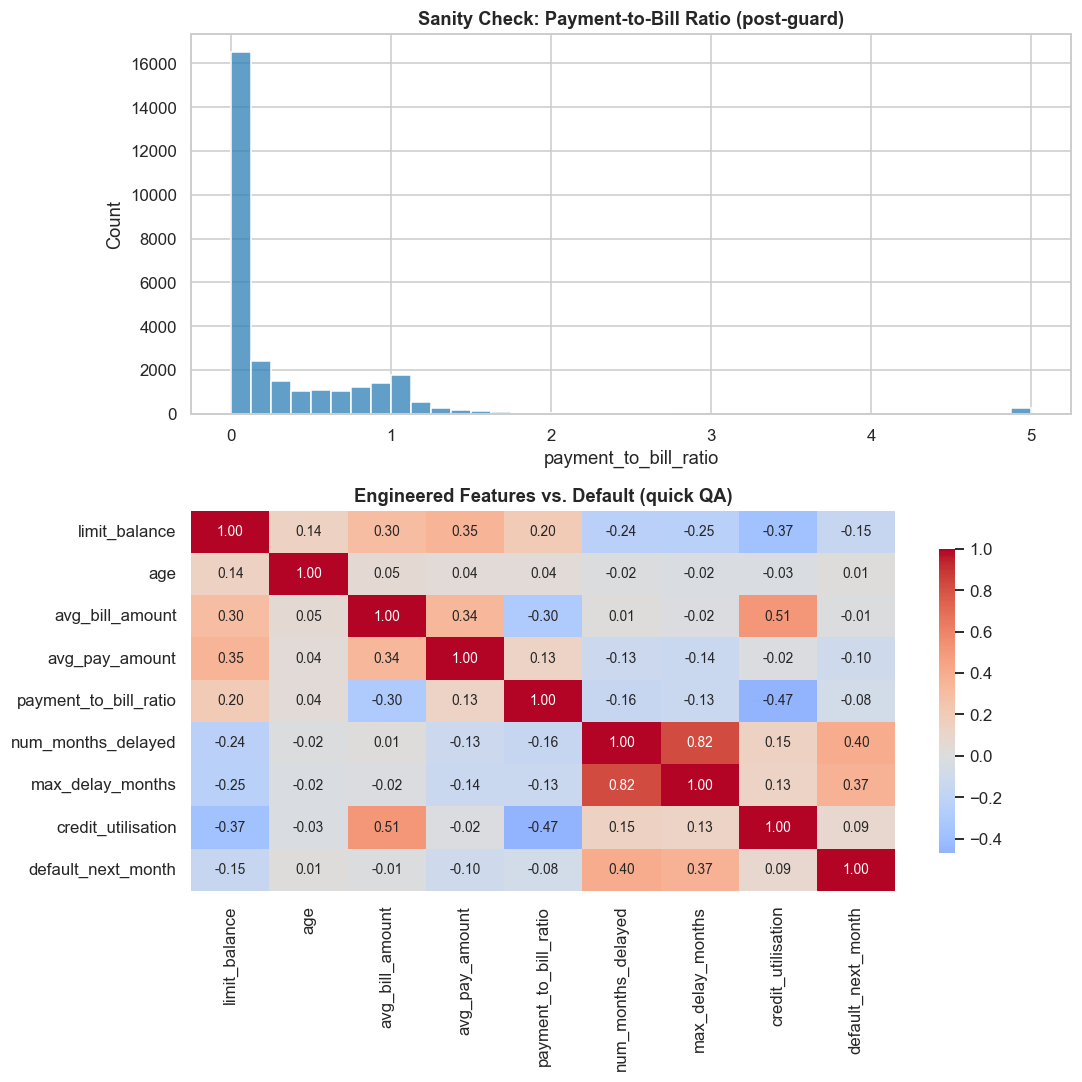

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sns.histplot(df["payment_to_bill_ratio"], bins=40, ax=axes[0], color="#2c7fb8")
axes[0].set_title("Sanity Check: Payment-to-Bill Ratio (post-guard)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("payment_to_bill_ratio")

corr_cols = [
    "limit_balance", "age", "avg_bill_amount", "avg_pay_amount",
    "payment_to_bill_ratio", "num_months_delayed", "max_delay_months",
    "credit_utilisation", "default_next_month",
]
corr = df[corr_cols].corr()

sns.heatmap(
    corr, 
    ax=axes[1], 
    cmap="coolwarm", 
    center=0, 
    annot=True, 
    fmt=".2f",
    annot_kws={"size": 9}, 
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Engineered Features vs. Default (quick QA)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Both the delinquency count and maximum-delay features already show the expected positive
relationship with `default_next_month`, and the payment-to-bill ratio guard has produced a
well-behaved, finite distribution — confirming the engineered features are ready for the deeper
Phase 2 exploratory analysis.

## 8. Final QA & Persist Cleaned Dataset

A last structural check, then export the cleaned dataset (and its data dictionary) for the rest
of the team, per the Phase 1 "Persist the Result" requirement.

In [44]:
def final_quality_report(frame: pd.DataFrame) -> pd.DataFrame:
    """Produce a compact final data-quality summary for handover."""
    report = pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "n_missing": frame.isnull().sum(),
        "pct_missing": (frame.isnull().mean() * 100).round(3),
        "n_unique": frame.nunique(),
    })
    return report


qa_report = final_quality_report(df)
print(f"Final cleaned shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Total missing values remaining: {int(df.isnull().sum().sum())}")
print(f"Remaining full-row duplicates: {df.duplicated().sum()}")
qa_report

Final cleaned shape: 30,000 rows x 39 columns
Total missing values remaining: 0
Remaining full-row duplicates: 0


,dtype,n_missing,pct_missing,n_unique
customer_id,int64,0,0.0,30000
limit_balance,int64,0,0.0,81
sex,int64,0,0.0,2
education,int64,0,0.0,7
marriage,int64,0,0.0,4
age,int64,0,0.0,56
pay_status_1,int64,0,0.0,11
pay_status_2,int64,0,0.0,11
pay_status_3,int64,0,0.0,11
pay_status_4,int64,0,0.0,11


In [45]:
df.to_csv(CLEAN_DATA_PATH, index=False)

qa_report.reset_index().rename(columns={"index": "column"}).to_csv(
    DATA_DICTIONARY_PATH, index=False
)

print(f"Cleaned dataset written to: {CLEAN_DATA_PATH.resolve()}")
print(f"Data dictionary written to: {DATA_DICTIONARY_PATH.resolve()}")
print(f"\nFinal dataset ready for Phase 2 (EDA): {df.shape[0]:,} rows x {df.shape[1]} columns")

Cleaned dataset written to: /Users/kalanamethsara/IdeaProjects/ITS2122_Credit_Risk_Analytics-Python_Group_Project/cleaned_credit_data.csv
Data dictionary written to: /Users/kalanamethsara/IdeaProjects/ITS2122_Credit_Risk_Analytics-Python_Group_Project/data_dictionary_cleaned.csv

Final dataset ready for Phase 2 (EDA): 30,000 rows x 39 columns


# Member 2 — Exploratory Data Analysis

Explores the cleaned dataset and statistically tests which factors relate to default.

**Work done:**
- Verified the cleaned data is analysis-ready (no nulls, no duplicate IDs)
- Calculated the overall default rate with a confidence interval
- Compared default rate across age, education, marital status, and credit-limit tier
- Analyzed delinquency history (months delayed) by default outcome
- Ranked each repayment-status month by how strongly it predicts default
- Ran significance tests (Mann-Whitney U, chi-square) on financial features and segments
- Built an age-band × limit-tier cross-tab of default rate

**Special features:**
- Uses the Wilson score interval (more accurate than the naive formula for a ~22% rate)
- Every group comparison includes an effect-size measure (Cramér's V or rank-biserial correlation), not just a p-value
- Identifies the most recent repayment month as the strongest early-warning signal

## 1. Environment Setup

In [46]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

CLEAN_DATA_PATH = Path("cleaned_credit_data.csv")
ALPHA = 0.05  # significance level used throughout this notebook

print("Environment ready.")

Environment ready.


## 2. Load Cleaned Data & Re-Verify Integrity

We never assume a handoff file is safe to use blindly — we re-run a lightweight integrity check
before analysing it.

In [47]:

def load_cleaned_data(path: Path) -> pd.DataFrame:
    """Load the Phase 1 cleaned dataset and verify it is analysis-ready.

    Parameters
    ----------
    path : Path
        Location of the cleaned CSV produced by the Data Engineer.

    Returns
    -------
    pd.DataFrame
        The cleaned, feature-engineered dataset.

    Raises
    ------
    FileNotFoundError
        If the file does not exist at the given path.
    AssertionError
        If the file still contains nulls, duplicate IDs, or is missing the
        target column — any of which would mean Phase 1 was not completed.
    """
    if not path.exists():
        raise FileNotFoundError(f"Cleaned data file not found at: {path.resolve()}")

    frame = pd.read_csv(path)

    assert frame.isnull().sum().sum() == 0, "Cleaned data still contains missing values."
    assert frame["customer_id"].is_unique, "Cleaned data still contains duplicate customer IDs."
    assert "default_next_month" in frame.columns, "Target column missing from cleaned data."

    return frame


df = load_cleaned_data(CLEAN_DATA_PATH)
print(f"Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Integrity checks passed: no nulls, no duplicate IDs, target column present.")
df.head(3)


Loaded cleaned dataset: 30,000 rows x 39 columns
Integrity checks passed: no nulls, no duplicate IDs, target column present.


,customer_id,limit_balance,sex,education,marriage,age,pay_status_1,pay_status_2,pay_status_3,pay_status_4,pay_status_5,pay_status_6,bill_amount_1,bill_amount_2,bill_amount_3,bill_amount_4,bill_amount_5,bill_amount_6,pay_amount_1,pay_amount_2,pay_amount_3,pay_amount_4,pay_amount_5,pay_amount_6,default_next_month,sex_label,education_label,marriage_label,limit_balance_outlier_flag,avg_bill_amount,avg_pay_amount,payment_to_bill_ratio,num_months_delayed,max_delay_months,balance_trend,balance_trend_label,credit_utilisation,limit_tier,age_band
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Female,University,Married,False,1284.000000,114.833333,0.089434,2,2,3913,Increasing,0.195650,Low,18-25
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Female,University,Single,False,2846.166667,833.333333,0.292791,2,2,-579,Stable,0.022350,Medium,26-35
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Female,University,Single,False,16942.166667,1836.333333,0.108388,0,0,13690,Increasing,0.324878,Medium,26-35


## 3. Overall Default Rate

The single most important number for the executive board's Executive Summary. We report it with
a **95% confidence interval** (Wilson score interval, robust for proportions) rather than a bare
point estimate, since the board will use this figure to size provisioning and collections budget.

In [48]:
def wilson_confidence_interval(successes: int, n: int, confidence: float = 0.95) -> tuple[float, float]:
    """Compute a Wilson score confidence interval for a binomial proportion.

    The Wilson interval is preferred over the naive normal-approximation
    interval because it stays within [0, 1] and remains accurate even for
    proportions far from 0.5, which is the case here (default rate ~22%).

    Parameters
    ----------
    successes : int
        Number of positive outcomes (defaults).
    n : int
        Total number of trials (accounts).
    confidence : float
        Confidence level, default 0.95.

    Returns
    -------
    tuple[float, float]
        Lower and upper bounds of the confidence interval.
    """
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denom = 1 + z ** 2 / n
    centre = p_hat + z ** 2 / (2 * n)
    margin = z * np.sqrt(p_hat * (1 - p_hat) / n + z ** 2 / (4 * n ** 2))
    return (centre - margin) / denom, (centre + margin) / denom


n_total = len(df)
n_default = int(df["default_next_month"].sum())
overall_rate = n_default / n_total
ci_low, ci_high = wilson_confidence_interval(n_default, n_total)

print(f"Portfolio size:            {n_total:,} accounts")
print(f"Defaulted next month:      {n_default:,} accounts")
print(f"Overall default rate:      {overall_rate:.2%}")
print(f"95% confidence interval:   [{ci_low:.2%}, {ci_high:.2%}]")

Portfolio size:            30,000 accounts
Defaulted next month:      6,636 accounts
Overall default rate:      22.12%
95% confidence interval:   [21.65%, 22.59%]


## 4. Default Rate by Demographic & Credit-Limit Segments

For each segment, we don't just report a default rate — we test **whether the differences across
groups are statistically significant** using a chi-square test of independence, and quantify the
strength of association with **Cramér's V** (0 = no association, 1 = perfect association). This
avoids over-interpreting small, noisy differences as real risk drivers.

In [49]:
def segment_default_summary(frame: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Summarise account count, default count, default rate, and 95% CI by segment.

    Parameters
    ----------
    frame : pd.DataFrame
        The cleaned dataset.
    group_col : str
        Categorical column to group by (e.g. 'age_band', 'education_label').

    Returns
    -------
    pd.DataFrame
        One row per segment level, sorted by default rate descending.
    """
    grouped = frame.groupby(group_col, observed=True)["default_next_month"].agg(
        n_accounts="count", n_default="sum"
    )
    grouped["default_rate"] = grouped["n_default"] / grouped["n_accounts"]

    ci_bounds = grouped.apply(
        lambda r: wilson_confidence_interval(int(r["n_default"]), int(r["n_accounts"])), axis=1
    )
    grouped["ci_low"] = ci_bounds.apply(lambda t: t[0])
    grouped["ci_high"] = ci_bounds.apply(lambda t: t[1])

    return grouped.sort_values("default_rate", ascending=False).reset_index()


def association_strength(frame: pd.DataFrame, group_col: str, target_col: str = "default_next_month") -> dict:
    """Run a chi-square test of independence and compute Cramer's V effect size.

    Returns
    -------
    dict
        chi2 statistic, p-value, degrees of freedom, and Cramer's V.
    """
    contingency = pd.crosstab(frame[group_col], frame[target_col])
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
    return {"chi2": chi2, "p_value": p_value, "dof": dof, "cramers_v": cramers_v}


SEGMENT_COLS = ["age_band", "education_label", "marriage_label", "limit_tier"]

segment_summaries = {col: segment_default_summary(df, col) for col in SEGMENT_COLS}
association_results = pd.DataFrame(
    {col: association_strength(df, col) for col in SEGMENT_COLS}
).T
association_results.index.name = "segment"
association_results["significant_at_5pct"] = association_results["p_value"] < ALPHA

print("Statistical significance of each segment's association with default:\n")
association_results


Statistical significance of each segment's association with default:



,chi2,p_value,dof,cramers_v,significant_at_5pct
segment,,,,,
age_band,113.495433,1.307117e-23,4.0,0.061508,True
education_label,160.589153,1.092874e-33,4.0,0.073164,True
marriage_label,35.662396,8.825862e-08,3.0,0.034478,True
limit_tier,819.016214,3.250906e-177,3.0,0.165229,True


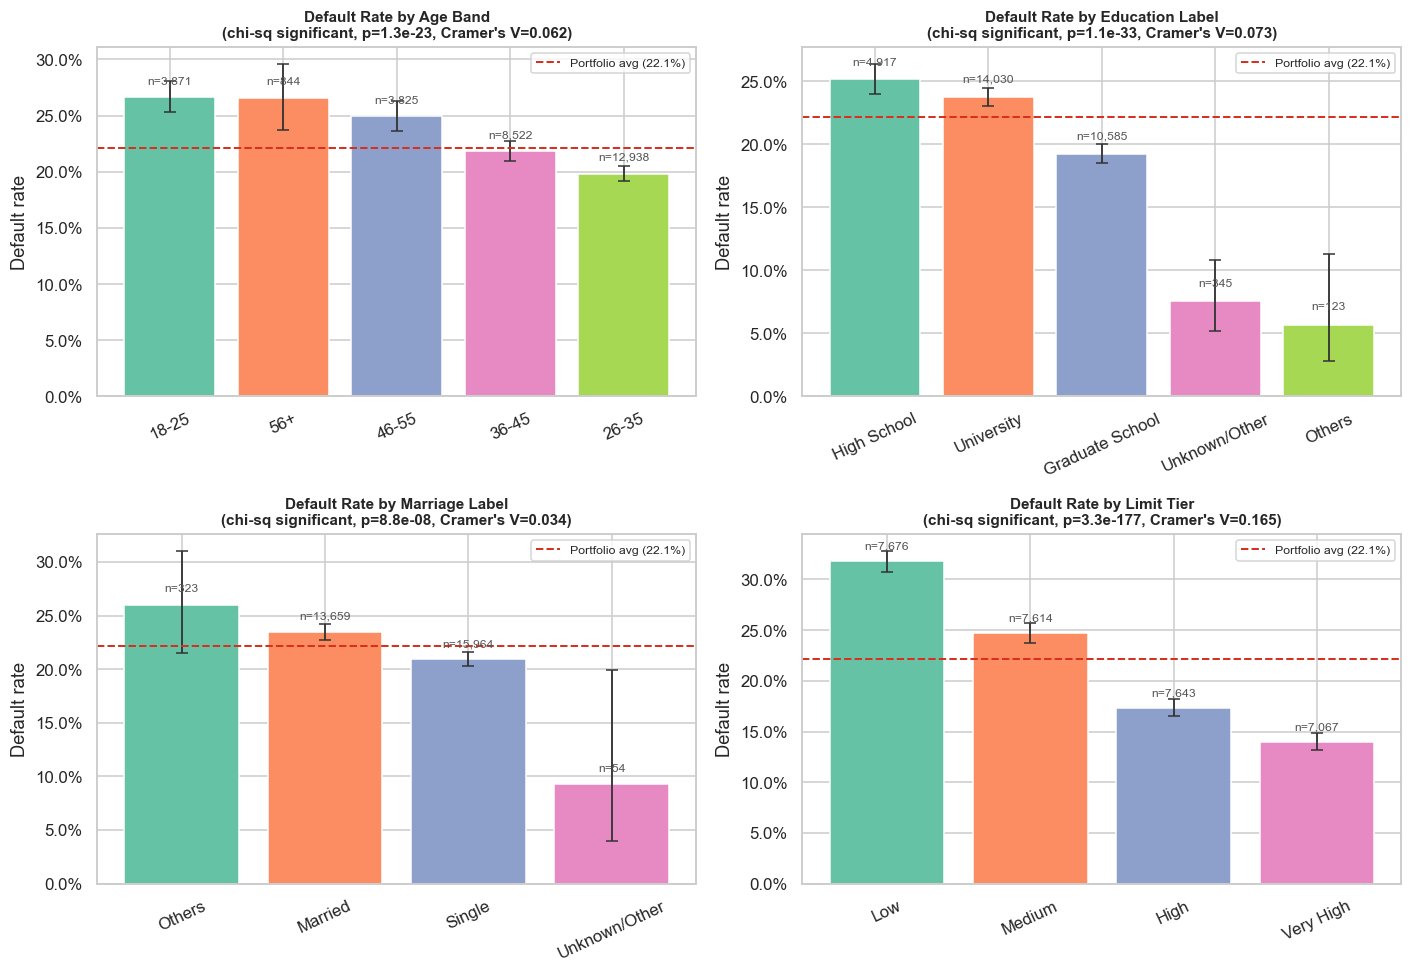

In [57]:

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

colors = sns.color_palette("Set2")

for ax, col in zip(axes, SEGMENT_COLS):
    summary = segment_summaries[col]
    
    bars = ax.bar(
        summary[col].astype(str), summary["default_rate"], 
        color=colors[:len(summary)],
        yerr=[summary["default_rate"] - summary["ci_low"], summary["ci_high"] - summary["default_rate"]],
        capsize=4, error_kw={"linewidth": 1.2, "ecolor": "#333333"}
    )
    
    ax.axhline(overall_rate, color="#d7301f", linestyle="--", linewidth=1.3,
               label=f"Portfolio avg ({overall_rate:.1%})")
    
    for bar, n_acc in zip(bars, summary["n_accounts"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"n={n_acc:,}", ha="center", va="bottom", fontsize=8, color="#555555")

    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    p_val = association_results.loc[col, "p_value"]
    v = association_results.loc[col, "cramers_v"]
    sig_tag = "significant" if p_val < ALPHA else "not significant"
    
    ax.set_title(f"Default Rate by {col.replace('_', ' ').title()}\n"
                 f"(chi-sq {sig_tag}, p={p_val:.1e}, Cramer's V={v:.3f})", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Default rate")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## 5. Repayment-Behaviour Analysis

The board's second question: *which repayment behaviours are the strongest early-warning
signals?* We answer this two ways: (a) comparing delinquency summary stats between defaulters and
non-defaulters, and (b) mapping default rate against repayment-status severity, month by month, to
find the single most predictive signal.

In [59]:
delinquency_by_outcome = df.groupby("default_next_month", observed=True)[
    ["num_months_delayed", "max_delay_months"]
].agg(["mean", "median", "std"]).round(2)
delinquency_by_outcome.index = ["No Default", "Default"]
delinquency_by_outcome

num_months_delayed              max_delay_months             
                         mean median   std             mean median   std
No Default                0.5    0.0  1.15             0.47    0.0  0.90
Default                   2.0    1.0  2.13             1.43    2.0  1.29

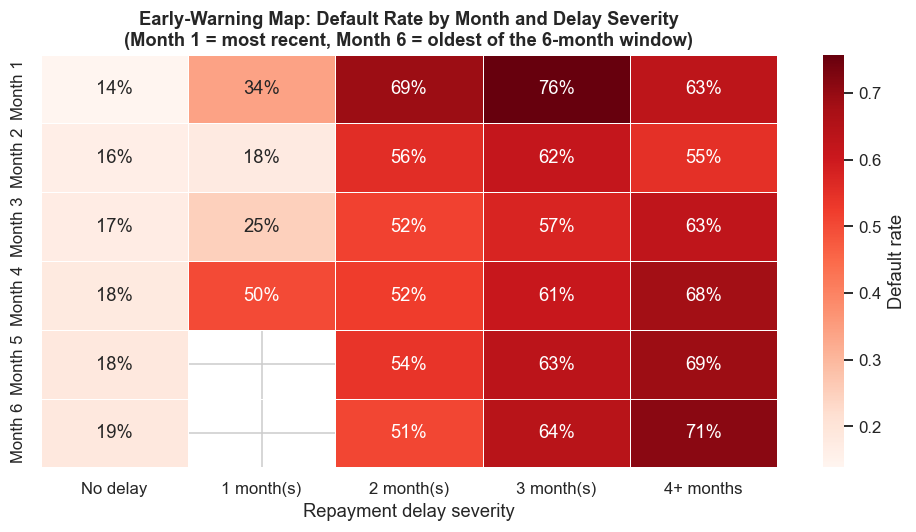

In [60]:
pay_status_cols = [f"pay_status_{m}" for m in range(1, 7)]

# Long-format table: one row per (customer, month, repayment status), for a month x severity view
long_pay = df.melt(
    id_vars=["customer_id", "default_next_month"],
    value_vars=pay_status_cols,
    var_name="month", value_name="pay_status",
)
long_pay["month"] = long_pay["month"].str.replace("pay_status_", "Month ", regex=False)

# Cap severity for a readable pivot: -2/-1/0 -> "No delay", 1..9 -> capped at 4+ for legibility
def bucket_severity(code: int) -> str:
    """Bucket a raw repayment-status code into a readable severity label."""
    if code <= 0:
        return "No delay"
    if code >= 4:
        return "4+ months"
    return f"{code} month(s)"


long_pay["severity"] = long_pay["pay_status"].apply(bucket_severity)

severity_order = ["No delay", "1 month(s)", "2 month(s)", "3 month(s)", "4+ months"]
pivot_default_rate = (
    long_pay.groupby(["month", "severity"], observed=True)["default_next_month"]
    .mean()
    .unstack("severity")
    .reindex(columns=severity_order)
    .reindex([f"Month {m}" for m in range(1, 7)])
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_default_rate, annot=True, fmt=".0%", cmap="Reds", ax=ax,
            cbar_kws={"label": "Default rate"}, linewidths=0.5, linecolor="white")
ax.set_title("Early-Warning Map: Default Rate by Month and Delay Severity\n"
              "(Month 1 = most recent, Month 6 = oldest of the 6-month window)")
ax.set_xlabel("Repayment delay severity")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [61]:
# Rank each month's raw repayment status by its point-biserial correlation with default —
# a direct, single-number measure of "how early-warning is this month's signal?"
correlation_by_month = []
for col in pay_status_cols:
    corr, p_val = stats.pointbiserialr(df["default_next_month"], df[col])
    correlation_by_month.append({"month": col, "correlation_with_default": corr, "p_value": p_val})

correlation_ranking = (
    pd.DataFrame(correlation_by_month)
    .sort_values("correlation_with_default", ascending=False)
    .reset_index(drop=True)
)
correlation_ranking

,month,correlation_with_default,p_value
0,pay_status_1,0.324794,0.000000e+00
1,pay_status_2,0.263551,0.000000e+00
2,pay_status_3,0.235253,0.000000e+00
3,pay_status_4,0.216614,1.899297e-315
4,pay_status_5,0.204149,1.126608e-279
5,pay_status_6,0.186866,7.296740e-234


## 6. Financial Position Analysis

Comparing bill amounts, payment amounts, and repayment capacity (`payment_to_bill_ratio`,
`credit_utilisation`) between defaulters and non-defaulters. These variables are heavily
right-skewed, so we use the **Mann-Whitney U test** (a non-parametric test of distributional
difference) rather than a t-test, and report **rank-biserial correlation** as the effect size.

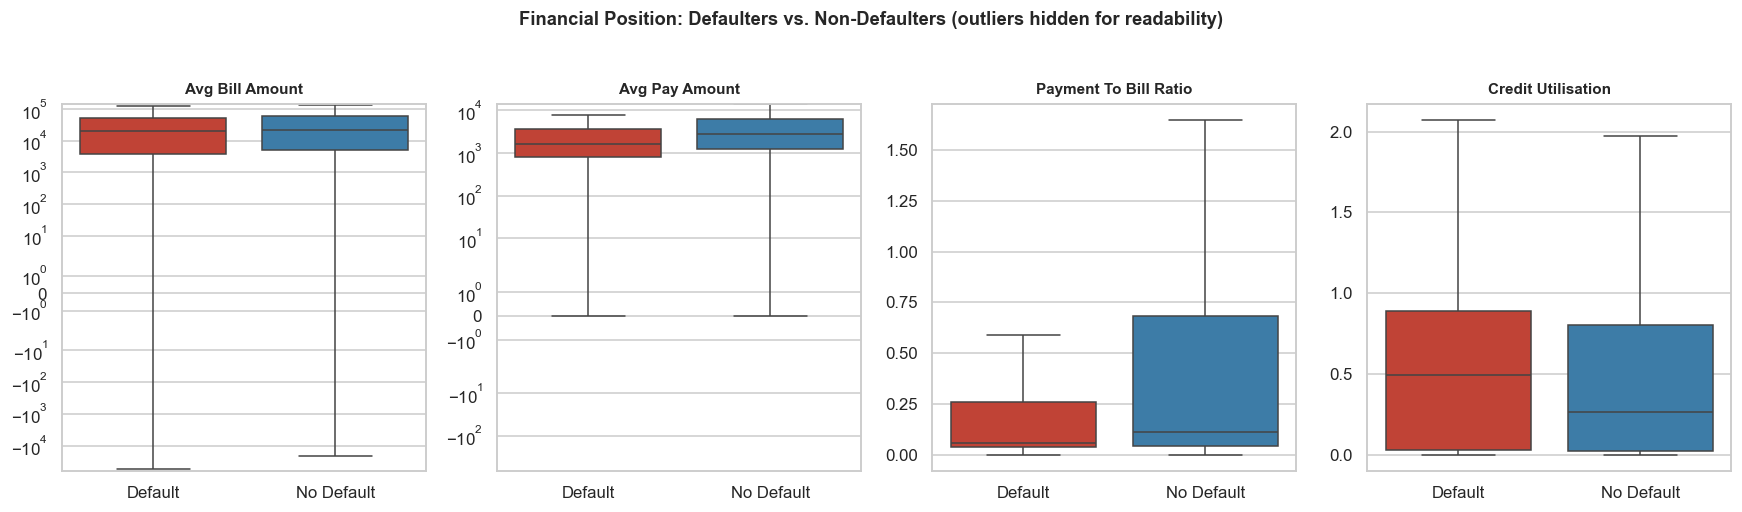

In [62]:
financial_cols = ["avg_bill_amount", "avg_pay_amount", "payment_to_bill_ratio", "credit_utilisation"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
outcome_labels = {0: "No Default", 1: "Default"}
plot_df = df.assign(outcome=df["default_next_month"].map(outcome_labels))

for ax, col in zip(axes, financial_cols):
    sns.boxplot(data=plot_df, x="outcome", y=col, hue="outcome", ax=ax,
                palette={"No Default": "#2c7fb8", "Default": "#d7301f"}, legend=False,
                showfliers=False)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if col in ("avg_bill_amount", "avg_pay_amount"):
        ax.set_yscale("symlog")

plt.suptitle("Financial Position: Defaulters vs. Non-Defaulters (outliers hidden for readability)",
             y=1.03, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [63]:
def mann_whitney_effect_size(frame: pd.DataFrame, col: str, group_col: str = "default_next_month") -> dict:
    """Run a Mann-Whitney U test between the two outcome groups and compute
    the rank-biserial correlation as a distribution-free effect size.

    Returns
    -------
    dict
        U statistic, p-value, and rank-biserial correlation (-1 to 1).
    """
    group_0 = frame.loc[frame[group_col] == 0, col]
    group_1 = frame.loc[frame[group_col] == 1, col]
    u_stat, p_value = stats.mannwhitneyu(group_1, group_0, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (len(group_0) * len(group_1))
    return {"U_statistic": u_stat, "p_value": p_value, "rank_biserial_corr": rank_biserial}


financial_test_results = pd.DataFrame(
    {col: mann_whitney_effect_size(df, col) for col in financial_cols}
).T
financial_test_results.index.name = "feature"
financial_test_results["significant_at_5pct"] = financial_test_results["p_value"] < ALPHA
financial_test_results

,U_statistic,p_value,rank_biserial_corr,significant_at_5pct
feature,,,,
avg_bill_amount,74628636.0,3.368955e-06,0.037320,True
avg_pay_amount,58744020.0,7.425614e-200,0.242225,True
payment_to_bill_ratio,62046827.0,2.168073e-136,0.199620,True
credit_utilisation,85340197.5,3.417572e-36,-0.100855,True


## 7. Bridge View: Credit-Limit Tier × Age Band Default Heatmap

A compact cross-tabulation that starts to answer the board's exposure question (Q3) using
Phase-2 tools, ahead of the formal exposure analysis in Phase 4.

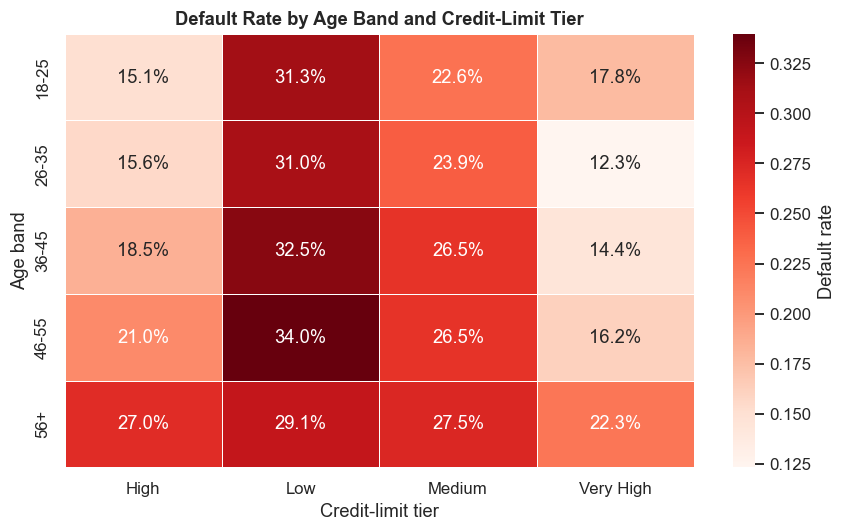

Underlying account counts per cell:


limit_tier,High,Low,Medium,Very High
age_band,,,,
18-25,372,2200,1181,118
26-35,3827,2371,3480,3260
36-45,2446,1697,1877,2502
46-55,824,1157,872,972
56+,174,251,204,215


In [64]:
cross_tab_rate = (
    df.pivot_table(index="age_band", columns="limit_tier", values="default_next_month",
                    aggfunc="mean", observed=True)
)
cross_tab_count = (
    df.pivot_table(index="age_band", columns="limit_tier", values="default_next_month",
                    aggfunc="count", observed=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cross_tab_rate, annot=True, fmt=".1%", cmap="Reds", ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Default rate"})
ax.set_title("Default Rate by Age Band and Credit-Limit Tier")
ax.set_xlabel("Credit-limit tier")
ax.set_ylabel("Age band")
plt.tight_layout()
plt.show()

print("Underlying account counts per cell:")
cross_tab_count


# Member 3 — Data Visualization

Turns the cleaned dataset into a consistent set of report-ready charts.

**Work done:**
- Set up a shared visual style (colors, fonts, DPI) used across every chart
- Produced 10 charts: default distribution, default rate by age/education/marital status/limit tier, credit-limit and utilisation boxplots by outcome, default rate vs. months delayed, and a correlation heatmap
- Exported all charts as PNGs to `report_figures/`

**Special features:**
- One fixed color pair (blue = no default, red = default) used everywhere for instant visual consistency
- Charts clip extreme outliers for display only, without altering the underlying data
- A reusable `save_fig()` helper keeps every export at consistent report quality

## 1. Setup & Visual Styling

A single consistent style is applied across every chart in this notebook — one color palette, one font
scale, one figure-size convention — so the visual portfolio reads as a coherent, professionally designed
set rather than a mix of default-matplotlib plots. This matters directly for the "Data Visualization"
rubric criterion (clear, correctly labelled, professionally formatted plots).

**Palette logic:** a neutral grey for the "no default" baseline and a strong red for "default" is used
consistently across every chart that splits by outcome, so a reader can recognise "red = risk" at a glance
throughout the whole report without re-reading each legend.

In [65]:

# --- Consistent visual style for the whole portfolio ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12

# Consistent semantic colors used across every default-split chart
COLOR_NO_DEFAULT = "#4C72B0"   # steel blue  = did not default
COLOR_DEFAULT    = "#C44E52"   # red         = defaulted
PALETTE_DEFAULT  = {0: COLOR_NO_DEFAULT, 1: COLOR_DEFAULT}
SEQ_PALETTE      = "Blues"     # for single-variable magnitude charts

# Where exported report images will be saved
OUTPUT_DIR = "report_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(fig, filename):
    """Save a figure to the report_figures/ folder at report quality."""
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, bbox_inches="tight", dpi=200)
    print(f"Saved: {path}")

print("Setup complete.")

Setup complete.


## 2. Load the Cleaned Dataset

Loading the output of Phase 1 (Member 1's cleaning pipeline). A quick integrity check confirms the
dataset arrived intact before any visualization work begins — this notebook assumes cleaning is already
done and does not re-clean or re-engineer features.

In [66]:
df = pd.read_csv("cleaned_credit_data.csv")

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
df.head(3)

Rows: 30,000  |  Columns: 39
Missing values remaining: 0


,customer_id,limit_balance,sex,education,marriage,age,pay_status_1,pay_status_2,pay_status_3,pay_status_4,pay_status_5,pay_status_6,bill_amount_1,bill_amount_2,bill_amount_3,bill_amount_4,bill_amount_5,bill_amount_6,pay_amount_1,pay_amount_2,pay_amount_3,pay_amount_4,pay_amount_5,pay_amount_6,default_next_month,sex_label,education_label,marriage_label,limit_balance_outlier_flag,avg_bill_amount,avg_pay_amount,payment_to_bill_ratio,num_months_delayed,max_delay_months,balance_trend,balance_trend_label,credit_utilisation,limit_tier,age_band
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Female,University,Married,False,1284.000000,114.833333,0.089434,2,2,3913,Increasing,0.195650,Low,18-25
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Female,University,Single,False,2846.166667,833.333333,0.292791,2,2,-579,Stable,0.022350,Medium,26-35
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Female,University,Single,False,16942.166667,1836.333333,0.108388,0,0,13690,Increasing,0.324878,Medium,26-35


In [67]:
# Confirm the categorical/engineered columns this notebook depends on are present
required_cols = [
    "default_next_month", "age_band", "education_label", "marriage_label",
    "limit_tier", "limit_balance", "payment_to_bill_ratio", "num_months_delayed",
    "credit_utilisation",
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing expected columns from Phase 1 output: {missing}"
print("All required columns present.")

# Human-readable label for the binary target, used as the legend/axis label
# on every chart that splits by default outcome.
df["default_label"] = df["default_next_month"].map({0: "No Default", 1: "Default"})

All required columns present.


## 3. Visual Portfolio

### Chart 1 — Overall Default Distribution

**Business question:** *What is the overall default rate?* This is the baseline every other segment gets
compared against later in the report.

Saved: report_figures/01_overall_default_distribution.png


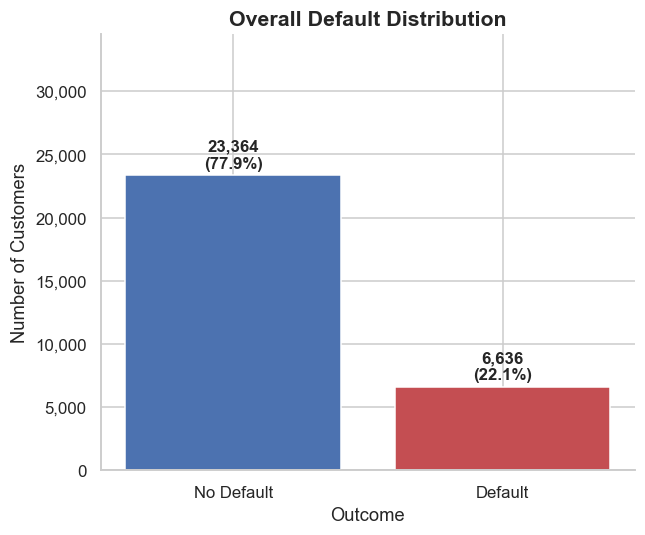

In [68]:
fig, ax = plt.subplots(figsize=(6, 5))

counts = df["default_label"].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[COLOR_NO_DEFAULT, COLOR_DEFAULT])

total = counts.sum()
for bar, value in zip(bars, counts.values):
    pct = value / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
            f"{value:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Overall Default Distribution")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of Customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, total * 1.15)
sns.despine()
plt.tight_layout()
save_fig(fig, "01_overall_default_distribution.png")
plt.show()

### Chart 2 — Default Rate by Age Band

**Business question:** *How does default risk vary across age bands?*

Saved: report_figures/02_default_rate_by_age_band.png


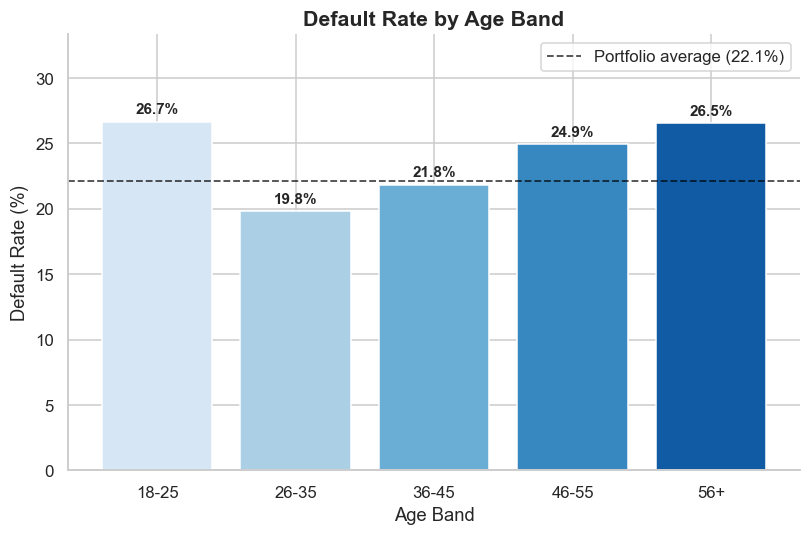

In [69]:
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]
age_default = df.groupby("age_band", observed=True)["default_next_month"].mean().reindex(age_order) * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(age_default.index, age_default.values, color=sns.color_palette(SEQ_PALETTE, len(age_default)))

overall_rate = df["default_next_month"].mean() * 100
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Portfolio average ({overall_rate:.1f}%)")

for bar, value in zip(bars, age_default.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Default Rate by Age Band")
ax.set_xlabel("Age Band")
ax.set_ylabel("Default Rate (%)")
ax.set_ylim(0, max(age_default.values) * 1.25)
ax.legend(loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
save_fig(fig, "02_default_rate_by_age_band.png")
plt.show()

### Chart 3 — Default Rate by Education Level

**Business question:** *How does default risk vary across education levels?*

Saved: report_figures/03_default_rate_by_education.png


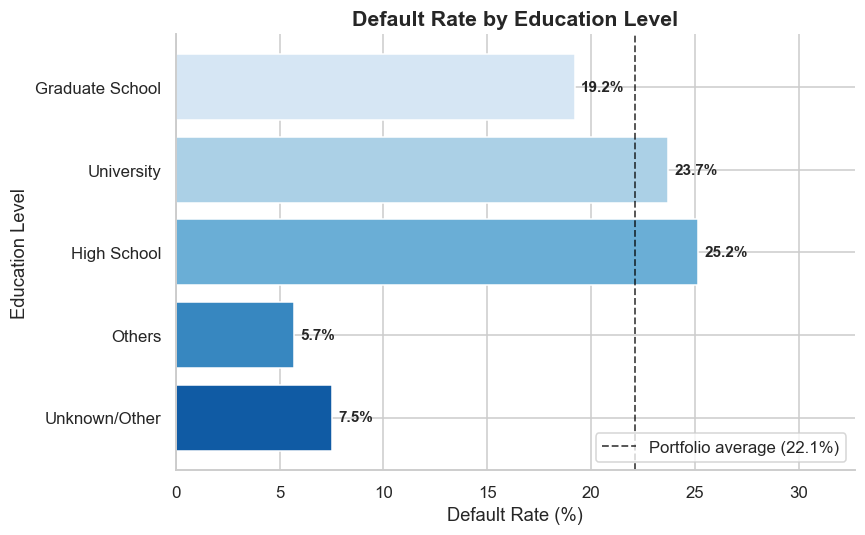

In [70]:
edu_order = ["Graduate School", "University", "High School", "Others", "Unknown/Other"]
edu_order = [e for e in edu_order if e in df["education_label"].unique()]
edu_default = df.groupby("education_label", observed=True)["default_next_month"].mean().reindex(edu_order) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(edu_default.index[::-1], edu_default.values[::-1],
                color=sns.color_palette(SEQ_PALETTE, len(edu_default))[::-1])

ax.axvline(overall_rate, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Portfolio average ({overall_rate:.1f}%)")

for bar, value in zip(bars, edu_default.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%", va="center", fontsize=10, fontweight="bold")

ax.set_title("Default Rate by Education Level")
ax.set_xlabel("Default Rate (%)")
ax.set_ylabel("Education Level")
ax.set_xlim(0, max(edu_default.values) * 1.3)
ax.legend(loc="lower right", frameon=True)
sns.despine()
plt.tight_layout()
save_fig(fig, "03_default_rate_by_education.png")
plt.show()

### Chart 4 — Default Rate by Marital Status

**Business question:** *How does default risk vary across marital status?*

Saved: report_figures/04_default_rate_by_marital_status.png


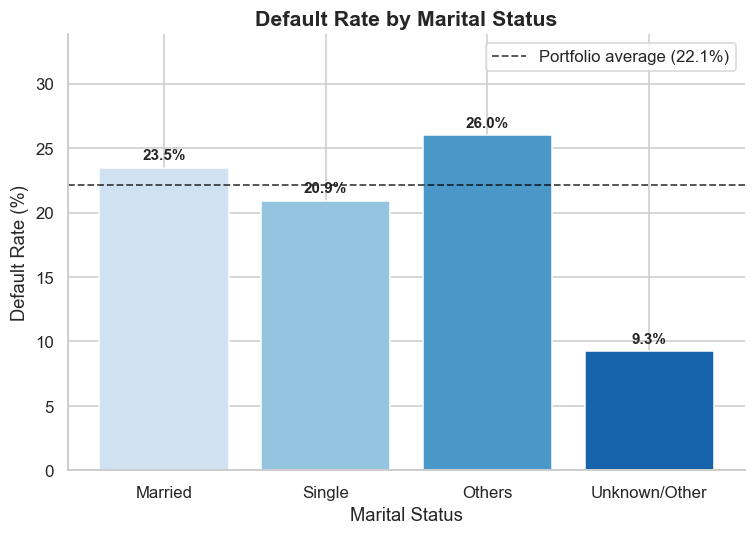

In [71]:
marriage_order = ["Married", "Single", "Others", "Unknown/Other"]
marriage_order = [m for m in marriage_order if m in df["marriage_label"].unique()]
marriage_default = df.groupby("marriage_label", observed=True)["default_next_month"].mean().reindex(marriage_order) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(marriage_default.index, marriage_default.values,
              color=sns.color_palette(SEQ_PALETTE, len(marriage_default)))

ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Portfolio average ({overall_rate:.1f}%)")

for bar, value in zip(bars, marriage_default.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Default Rate by Marital Status")
ax.set_xlabel("Marital Status")
ax.set_ylabel("Default Rate (%)")
ax.set_ylim(0, max(marriage_default.values) * 1.3)
ax.legend(loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
save_fig(fig, "04_default_rate_by_marital_status.png")
plt.show()

### Chart 5 — Default Rate by Credit-Limit Tier

**Business question:** *Which credit-limit tiers carry the greatest risk?* Directly informs the board's
"Credit Exposure vs. Capacity" question.

Saved: report_figures/05_default_rate_by_limit_tier.png


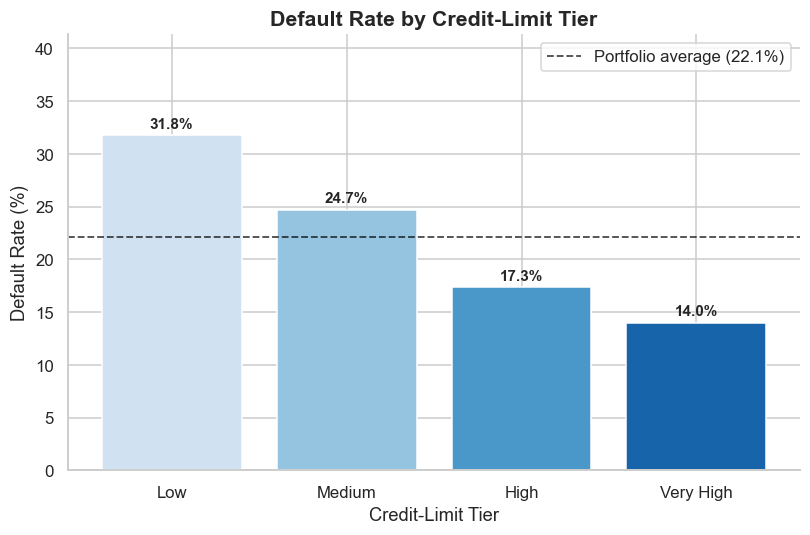

In [72]:
tier_order = ["Low", "Medium", "High", "Very High"]
tier_order = [t for t in tier_order if t in df["limit_tier"].unique()]
tier_default = df.groupby("limit_tier", observed=True)["default_next_month"].mean().reindex(tier_order) * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(tier_default.index, tier_default.values,
              color=sns.color_palette(SEQ_PALETTE, len(tier_default)))

ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Portfolio average ({overall_rate:.1f}%)")

for bar, value in zip(bars, tier_default.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Default Rate by Credit-Limit Tier")
ax.set_xlabel("Credit-Limit Tier")
ax.set_ylabel("Default Rate (%)")
ax.set_ylim(0, max(tier_default.values) * 1.3)
ax.legend(loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
save_fig(fig, "05_default_rate_by_limit_tier.png")
plt.show()

### Chart 6 — Credit Limit Distribution by Default Outcome

**Business question:** *Where is the company over-exposed?* A boxplot shows the full spread, not just
the average, so outlier high-limit defaulters are visible.

Saved: report_figures/06_credit_limit_by_default.png


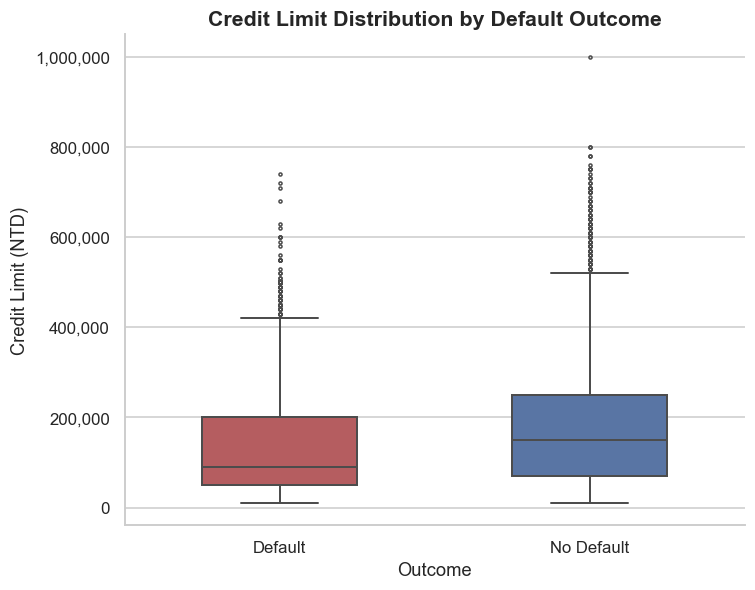

In [73]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.boxplot(data=df, x="default_label", y="limit_balance", hue="default_label",
            palette={"No Default": COLOR_NO_DEFAULT, "Default": COLOR_DEFAULT},
            legend=False, ax=ax, width=0.5, fliersize=2, linewidth=1.3)

ax.set_title("Credit Limit Distribution by Default Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("Credit Limit (NTD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
save_fig(fig, "06_credit_limit_by_default.png")
plt.show()

### Chart 7 — Payment-to-Bill Ratio by Default Outcome

**Business question:** *Which repayment behaviours are the strongest early-warning signals?* The
payment-to-bill ratio (engineered in Phase 1) is one of the clearest behavioural indicators available.
Extreme outlier ratios are clipped at the 99th percentile purely for chart readability — the underlying
data used for modelling in Phase 3 is untouched.

Saved: report_figures/07_payment_to_bill_ratio_by_default.png


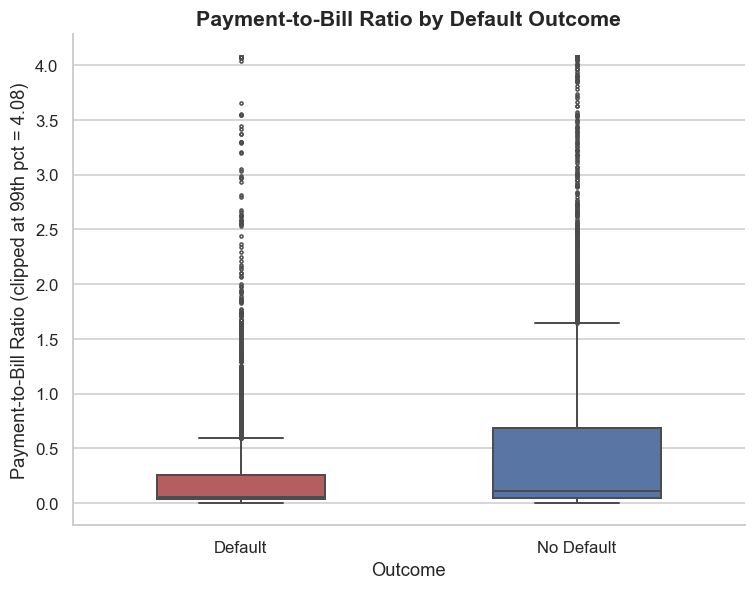

In [74]:
# Clip only for chart display so a handful of extreme outlier ratios don't
# compress the box for the other 99% of customers into an unreadable sliver.
clip_upper = df["payment_to_bill_ratio"].quantile(0.99)
plot_df = df.copy()
plot_df["payment_to_bill_ratio_display"] = plot_df["payment_to_bill_ratio"].clip(upper=clip_upper)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.boxplot(data=plot_df, x="default_label", y="payment_to_bill_ratio_display", hue="default_label",
            palette={"No Default": COLOR_NO_DEFAULT, "Default": COLOR_DEFAULT},
            legend=False, ax=ax, width=0.5, fliersize=2, linewidth=1.3)

ax.set_title("Payment-to-Bill Ratio by Default Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel(f"Payment-to-Bill Ratio (clipped at 99th pct = {clip_upper:.2f})")
sns.despine()
plt.tight_layout()
save_fig(fig, "07_payment_to_bill_ratio_by_default.png")
plt.show()

### Chart 8 — Number of Months Delayed vs. Default Rate

**Business question:** *How do repayment delays over the recent months relate to default likelihood?*
This is the single strongest early-warning signal expected in the dataset.

Saved: report_figures/08_default_rate_by_months_delayed.png


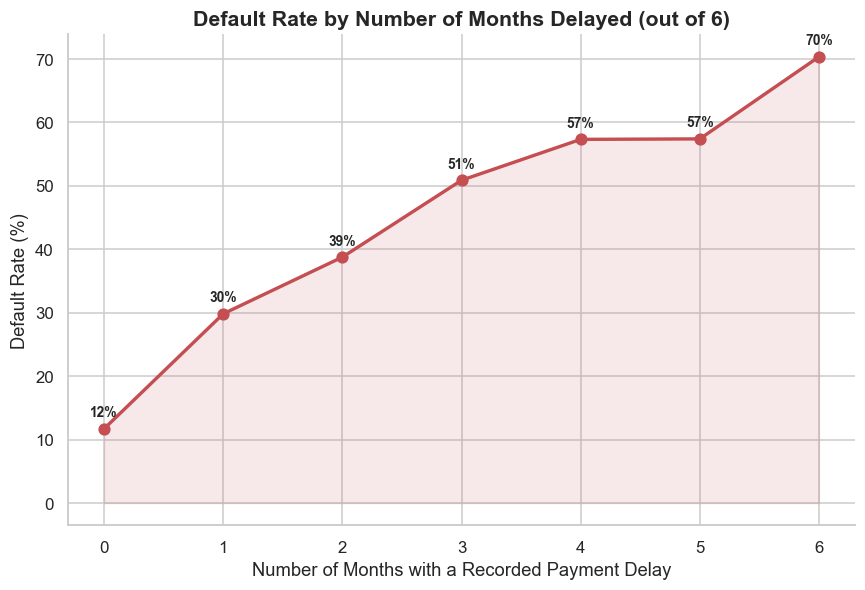

In [75]:
delay_default = df.groupby("num_months_delayed")["default_next_month"].agg(["mean", "count"])
delay_default = delay_default[delay_default["count"] >= 20]  # drop near-empty bins for a stable line
delay_default["rate_pct"] = delay_default["mean"] * 100

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(delay_default.index, delay_default["rate_pct"], marker="o", markersize=7,
        color=COLOR_DEFAULT, linewidth=2.2)
ax.fill_between(delay_default.index, delay_default["rate_pct"], color=COLOR_DEFAULT, alpha=0.12)

for x, y in zip(delay_default.index, delay_default["rate_pct"]):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, fontweight="bold")

ax.set_title("Default Rate by Number of Months Delayed (out of 6)")
ax.set_xlabel("Number of Months with a Recorded Payment Delay")
ax.set_ylabel("Default Rate (%)")
ax.set_xticks(delay_default.index)
sns.despine()
plt.tight_layout()
save_fig(fig, "08_default_rate_by_months_delayed.png")
plt.show()

### Chart 9 — Credit Utilisation by Default Outcome

**Business question:** *Are customers using a large share of their available credit more likely to
default?* This directly previews the Phase 4 utilisation-and-exposure hypothesis the board asked about,
giving the report a visual bridge between the EDA and strategy sections.

Saved: report_figures/09_credit_utilisation_by_default.png


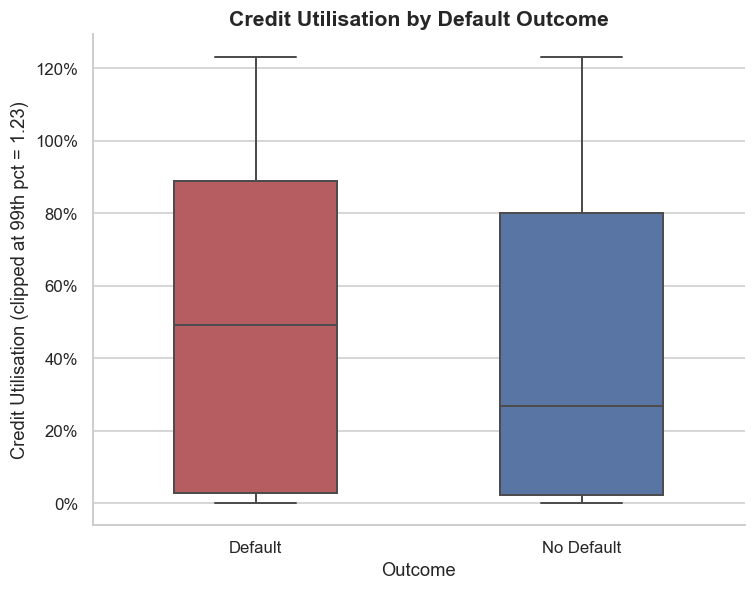

In [76]:
clip_util = df["credit_utilisation"].quantile(0.99)
plot_df["credit_utilisation_display"] = plot_df["credit_utilisation"].clip(upper=clip_util)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.boxplot(data=plot_df, x="default_label", y="credit_utilisation_display", hue="default_label",
            palette={"No Default": COLOR_NO_DEFAULT, "Default": COLOR_DEFAULT},
            legend=False, ax=ax, width=0.5, fliersize=2, linewidth=1.3)

ax.set_title("Credit Utilisation by Default Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel(f"Credit Utilisation (clipped at 99th pct = {clip_util:.2f})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
sns.despine()
plt.tight_layout()
save_fig(fig, "09_credit_utilisation_by_default.png")
plt.show()

### Chart 10 — Correlation Heatmap of Key Numeric Features

**Business question:** *How do credit limit, bills, payments, and delays relate to default, and to each
other?* Required by Section 3.2, Point 4 of the specification. A focused subset of features is used
rather than all ~35 columns — a full 35x35 heatmap is unreadable and would bury the signal the board
actually needs to see.

Saved: report_figures/10_correlation_heatmap.png


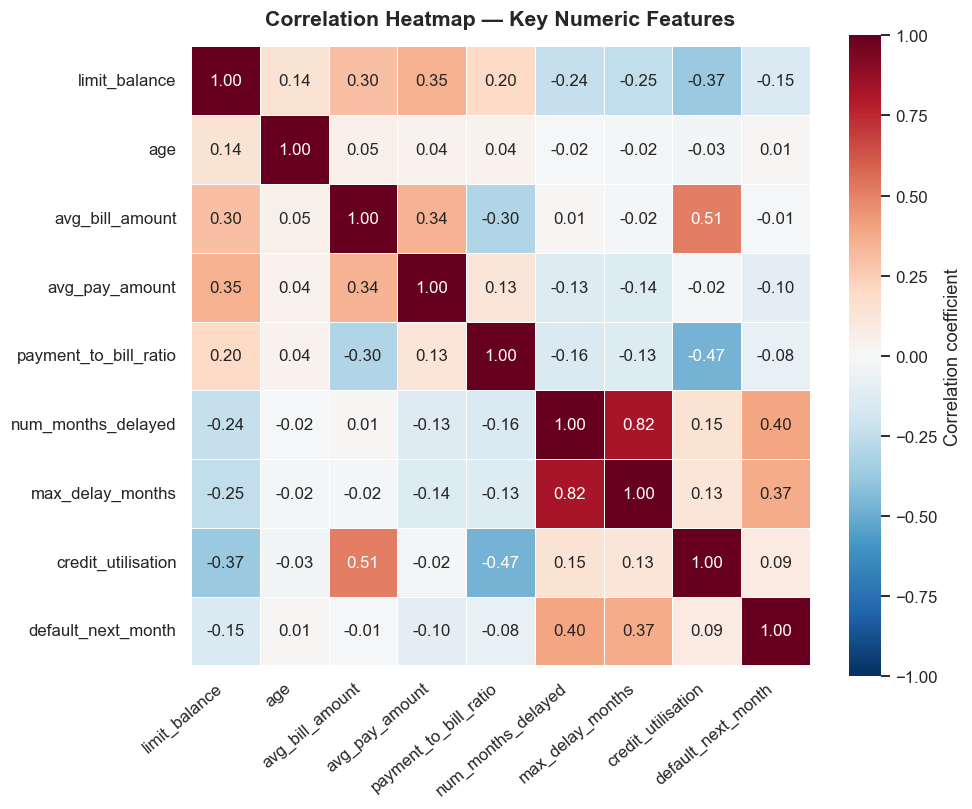

In [77]:
corr_features = [
    "limit_balance", "age", "avg_bill_amount", "avg_pay_amount",
    "payment_to_bill_ratio", "num_months_delayed", "max_delay_months",
    "credit_utilisation", "default_next_month",
]

corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.6, linecolor="white",
    cbar_kws={"label": "Correlation coefficient"}, ax=ax,
)

ax.set_title("Correlation Heatmap — Key Numeric Features", pad=14)
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
save_fig(fig, "10_correlation_heatmap.png")
plt.show()

## 4. Export Summary

All ten figures have been saved to the `report_figures/` folder at 200 DPI, suitable for direct placement
into the Strategic Insights Report PDF (Section 4.1, "Credit Risk & Repayment Analysis"). The cell below
lists every exported file for a final check before handing off to Member 5 for report assembly.

In [78]:
exported = sorted(os.listdir(OUTPUT_DIR))
print(f"{len(exported)} figures exported to '{OUTPUT_DIR}/':\n")
for f in exported:
    print(f"  - {f}")

10 figures exported to 'report_figures/':

  - 01_overall_default_distribution.png
  - 02_default_rate_by_age_band.png
  - 03_default_rate_by_education.png
  - 04_default_rate_by_marital_status.png
  - 05_default_rate_by_limit_tier.png
  - 06_credit_limit_by_default.png
  - 07_payment_to_bill_ratio_by_default.png
  - 08_default_rate_by_months_delayed.png
  - 09_credit_utilisation_by_default.png
  - 10_correlation_heatmap.png
